In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Pipeline utilisé pour construire mon modèle de détection de fraude


import modules

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import requests

import du fichier .CSV et exploration des données

In [ ]:
url = "/content/drive/MyDrive/transferX/fraudTrain.csv"

df = pd.read_csv("/content/drive/MyDrive/transferX/fraudTrain.csv", sep= ",")

df.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


 2.Prise d'information globale des colonnes( sont t'elles textuelles, numériques, nulles,etc...)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

Nettoyage & Préparation des données (Pandas)

In [ ]:
# colonnes importantes à garder
main_columns= df[['is_fraud','amt','state','trans_date_trans_time','merchant','city','category','first','last','merch_lat','merch_long','lat','long','cc_num']]
main_columns.head(5)


,is_fraud,amt,state,trans_date_trans_time,merchant,city,category,first,last,merch_lat,merch_long,lat,long,cc_num
0,0,4.97,NC,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",Moravian Falls,misc_net,Jennifer,Banks,36.011293,-82.048315,36.0788,-81.1781,2703186189652095
1,0,107.23,WA,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",Orient,grocery_pos,Stephanie,Gill,49.159047,-118.186462,48.8878,-118.2105,630423337322
2,0,220.11,ID,2019-01-01 00:00:51,fraud_Lind-Buckridge,Malad City,entertainment,Edward,Sanchez,43.150704,-112.154481,42.1808,-112.2620,38859492057661
3,0,45.00,MT,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",Boulder,gas_transport,Jeremy,White,47.034331,-112.561071,46.2306,-112.1138,3534093764340240
4,0,41.96,VA,2019-01-01 00:03:06,fraud_Keeling-Crist,Doe Hill,misc_pos,Tyler,Garcia,38.674999,-78.632459,38.4207,-79.4629,375534208663984


je fais une copie du Dataframe de préserver l'original :

In [ ]:
df_copy = df.copy()
df_copy.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


fusion Prenom/nom

In [ ]:

columns_keep = df_copy[['first','last']].copy() #selectionne'first' et 'last' sous le nom columns_keep
columns_keep['full_name'] = columns_keep['first'] + ' '+ columns_keep['last']# je fusionne les 2 colonnes
full_name= columns_keep[['full_name']] #je renomme la colonne fusionner
full_name.head(10)

,full_name
0,Jennifer Banks
1,Stephanie Gill
2,Edward Sanchez
3,Jeremy White
4,Tyler Garcia
5,Jennifer Conner
6,Kelsey Richards
7,Steven Williams
8,Heather Chase
9,Melissa Aguilar


je colle la colonne full_name avec le df principal :

In [ ]:
df_copy['full_name'] = full_name
df_copy.head(9)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,full_name
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,Jennifer Banks
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,Stephanie Gill
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,Edward Sanchez
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,Jeremy White
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,Tyler Garcia
5,5,2019-01-01 00:04:08,4767265376804500,"fraud_Stroman, Hudson and Erdman",gas_transport,94.63,Jennifer,Conner,F,4655 David Island,...,-75.2045,2158,Transport planner,1961-06-19,189a841a0a8ba03058526bcfe566aab5,1325376248,40.653382,-76.152667,0,Jennifer Conner
6,6,2019-01-01 00:04:42,30074693890476,fraud_Rowe-Vandervort,grocery_net,44.54,Kelsey,Richards,F,889 Sarah Station Suite 624,...,-100.9893,2691,Arboriculturist,1993-08-16,83ec1cc84142af6e2acf10c44949e720,1325376282,37.162705,-100.153370,0,Kelsey Richards
7,7,2019-01-01 00:05:08,6011360759745864,fraud_Corwin-Collins,gas_transport,71.65,Steven,Williams,M,231 Flores Pass Suite 720,...,-78.6003,6018,"Designer, multimedia",1947-08-21,6d294ed2cc447d2c71c7171a3d54967c,1325376308,38.948089,-78.540296,0,Steven Williams
8,8,2019-01-01 00:05:18,4922710831011201,fraud_Herzog Ltd,misc_pos,4.27,Heather,Chase,F,6888 Hicks Stream Suite 954,...,-79.6607,1472,Public affairs consultant,1941-03-07,fc28024ce480f8ef21a32d64c93a29f5,1325376318,40.351813,-79.958146,0,Heather Chase


 Conversion des textes en Date et extraction des heures :

In [ ]:
#converti  texte en date

df_copy['trans_date_trans_time']= pd.to_datetime(df_copy['trans_date_trans_time'])

#extrait heure et semaines :
df_copy['hour'] = df_copy['trans_date_trans_time'].dt.hour

df_copy['week'] = df_copy['trans_date_trans_time'].dt.dayofweek



#supprime "trans_date_trans_time":
df_copy = df_copy.drop(['trans_date_trans_time'],axis = 1)



df_copy




,Unnamed: 0,cc_num,merchant,category,amt,first,last,gender,street,city,...,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,full_name,hour,week
0,0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,Jennifer Banks,0,1
1,1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,Stephanie Gill,0,1
2,2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,Edward Sanchez,0,1
3,3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,Jeremy White,0,1
4,4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,Tyler Garcia,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,...,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0,Erik Patterson,12,6
1296671,1296671,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,...,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,Jeffrey White,12,6
1296672,1296672,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,...,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,Christopher Castaneda,12,6
1296673,1296673,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,...,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,Joseph Murray,12,6


Renommer 'week' en 'day':

In [ ]:
#renomme semaine en jour
df_copy = df_copy.rename(columns={'week':'day'})

df_copy

,Unnamed: 0,cc_num,merchant,category,amt,first,last,gender,street,city,...,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,full_name,hour,day
0,0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,Jennifer Banks,0,1
1,1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,Stephanie Gill,0,1
2,2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,Edward Sanchez,0,1
3,3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,Jeremy White,0,1
4,4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,Tyler Garcia,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,...,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0,Erik Patterson,12,6
1296671,1296671,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,...,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,Jeffrey White,12,6
1296672,1296672,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,...,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,Christopher Castaneda,12,6
1296673,1296673,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,...,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,Joseph Murray,12,6


In [ ]:
#frequence des fraudes;
df_copy['is_fraud'].value_counts()

,count
is_fraud,
0,1289169
1,7506


verification dude l'ensemble du  dataframe

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 25 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   Unnamed: 0  1296675 non-null  int64  
 1   cc_num      1296675 non-null  int64  
 2   merchant    1296675 non-null  object 
 3   category    1296675 non-null  object 
 4   amt         1296675 non-null  float64
 5   first       1296675 non-null  object 
 6   last        1296675 non-null  object 
 7   gender      1296675 non-null  object 
 8   street      1296675 non-null  object 
 9   city        1296675 non-null  object 
 10  state       1296675 non-null  object 
 11  zip         1296675 non-null  int64  
 12  lat         1296675 non-null  float64
 13  long        1296675 non-null  float64
 14  city_pop    1296675 non-null  int64  
 15  job         1296675 non-null  object 
 16  dob         1296675 non-null  object 
 17  trans_num   1296675 non-null  object 
 18  unix_time   1296675 no

 colonnes sélectionner stocker ds une variable

In [ ]:
columns_select = df_copy[['is_fraud','amt','hour', 'day','merchant','city','category','full_name','cc_num']]
columns_select.head(10)

,is_fraud,amt,hour,day,merchant,city,category,full_name,cc_num
0,0,4.97,0,1,"fraud_Rippin, Kub and Mann",Moravian Falls,misc_net,Jennifer Banks,2703186189652095
1,0,107.23,0,1,"fraud_Heller, Gutmann and Zieme",Orient,grocery_pos,Stephanie Gill,630423337322
2,0,220.11,0,1,fraud_Lind-Buckridge,Malad City,entertainment,Edward Sanchez,38859492057661
3,0,45.00,0,1,"fraud_Kutch, Hermiston and Farrell",Boulder,gas_transport,Jeremy White,3534093764340240
4,0,41.96,0,1,fraud_Keeling-Crist,Doe Hill,misc_pos,Tyler Garcia,375534208663984
5,0,94.63,0,1,"fraud_Stroman, Hudson and Erdman",Dublin,gas_transport,Jennifer Conner,4767265376804500
6,0,44.54,0,1,fraud_Rowe-Vandervort,Holcomb,grocery_net,Kelsey Richards,30074693890476
7,0,71.65,0,1,fraud_Corwin-Collins,Edinburg,gas_transport,Steven Williams,6011360759745864
8,0,4.27,0,1,fraud_Herzog Ltd,Manor,misc_pos,Heather Chase,4922710831011201
9,0,198.39,0,1,"fraud_Schoen, Kuphal and Nitzsche",Clarksville,grocery_pos,Melissa Aguilar,2720830304681674


 ici commmence les Features afin de mesurer l'écart entre domicile de chaque clients et le magasin ou l'achat est effectué:

In [ ]:
# Calcul de la distance brute (Pythagore version simple)
# On mesure l'écart entre le domicile et le magasin  pour chaque magasin lignes par lignes / j'utilise le théorem de Pythagore :
df_copy['dist_client_merch_km'] = ((df_copy['lat'] - df_copy['merch_lat'])**2 + (df_copy['long'] - df_copy['merch_long'])**2)**0.5 * 111 #1 degré de lattitude = 111km //Tu mets au carré (**2) pour calculer tes côtés, puis tu réduis par **0.5 pour retrouver ta diagonale

df_copy['dist_client_merch_km'] = df_copy['dist_client_merch_km'].round(2) #on arrondi à 2
df_copy['dist_client_merch_km']

,dist_client_merch_km
0,96.88
1,30.23
2,108.32
3,102.10
4,96.40
...,...
1296670,130.73
1296671,90.98
1296672,107.40
1296673,99.76


In [ ]:
#.transform('mean') calcule la moyenne de distance_km pour chaque clients // .transform rajoute une nouvelle colonne

distance_moyen = df_copy.groupby('cc_num')['dist_client_merch_km'].transform('mean').round(2)

df_copy['dist_moyen_habitude']= distance_moyen
df_copy['dist_moyen_habitude']

,dist_moyen_habitude
0,85.80
1,85.25
2,83.85
3,83.73
4,84.10
...,...
1296670,84.62
1296671,86.39
1296672,84.39
1296673,85.54


je définis une colonne 'ration comportementale' qui servira de mesure pour identifier les anomalies

In [ ]:
#ratio comportementale : l'écart par rapport à l'habitude

df_copy['ratio_distance'] = (df_copy['dist_client_merch_km']  / distance_moyen ).round(2) #on prend chaque distance au km que l'on compare à chaque distance moyenne
df_copy['ratio_distance']

,ratio_distance
0,1.13
1,0.35
2,1.29
3,1.22
4,1.15
...,...
1296670,1.54
1296671,1.05
1296672,1.27
1296673,1.17


affichage des indicateurs qui aideront à identifier les anomalies

In [ ]:
select_feature= df_copy[['dist_client_merch_km','dist_moyen_habitude','ratio_distance']]
select_feature

,dist_client_merch_km,dist_moyen_habitude,ratio_distance
0,96.88,85.80,1.13
1,30.23,85.25,0.35
2,108.32,83.85,1.29
3,102.10,83.73,1.22
4,96.40,84.10,1.15
...,...,...,...
1296670,130.73,84.62,1.54
1296671,90.98,86.39,1.05
1296672,107.40,84.39,1.27
1296673,99.76,85.54,1.17


affichage  du nombre de lignes et de colonnes

In [ ]:
df_copy.shape

(1296675, 28)

In [ ]:
#je calcule la moyenne des achats par clients
achat_moyen_client = df_copy.groupby('cc_num')['amt'].transform('mean').round(2)


#ratio achat moyen par clients :
df_copy['ratio_amount_vs_client'] = (df_copy['amt'] / achat_moyen_client).round(2)

df_copy['ratio_amount_vs_client']



,ratio_amount_vs_client
0,0.06
1,1.99
2,3.34
3,0.62
4,0.44
...,...
1296670,0.25
1296671,0.51
1296672,1.62
1296673,0.78


 je renomme l'ensemble en df_copy_final

In [ ]:
colonnes_def = ['is_fraud','amt','hour', 'day','city','category','dist_client_merch_km','dist_moyen_habitude','ratio_distance','ratio_amount_vs_client']
df_copy_final = df_copy[colonnes_def] #on récupére la variable avec les noms ds la liste

df_copy_final

,is_fraud,amt,hour,day,city,category,dist_client_merch_km,dist_moyen_habitude,ratio_distance,ratio_amount_vs_client
0,0,4.97,0,1,Moravian Falls,misc_net,96.88,85.80,1.13,0.06
1,0,107.23,0,1,Orient,grocery_pos,30.23,85.25,0.35,1.99
2,0,220.11,0,1,Malad City,entertainment,108.32,83.85,1.29,3.34
3,0,45.00,0,1,Boulder,gas_transport,102.10,83.73,1.22,0.62
4,0,41.96,0,1,Doe Hill,misc_pos,96.40,84.10,1.15,0.44
...,...,...,...,...,...,...,...,...,...,...
1296670,0,15.56,12,6,Hatch,entertainment,130.73,84.62,1.54,0.25
1296671,0,51.70,12,6,Tuscarora,food_dining,90.98,86.39,1.05,0.51
1296672,0,105.93,12,6,High Rolls Mountain Park,food_dining,107.40,84.39,1.27,1.62
1296673,0,74.90,12,6,Manderson,food_dining,99.76,85.54,1.17,0.78


In [ ]:
#j'enregistre le .csv
df_copy_final.to_csv('df_final.csv', index = False)

Modélisation Machine Learning

import modules:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, recall_score


 chargement du fichier nettoyé:

In [ ]:
url = "/content/drive/MyDrive/transferX/Data_cleaned/df_final.csv"

df = pd.read_csv("/content/drive/MyDrive/transferX/Data_cleaned/df_final.csv", sep= ",")

df.head(5)

,is_fraud,amt,hour,day,city,category,dist_client_merch_km,dist_moyen_habitude,ratio_distance,ratio_amount_vs_client
0,0,4.97,0,1,Moravian Falls,misc_net,96.88,85.80,1.13,0.06
1,0,107.23,0,1,Orient,grocery_pos,30.23,85.25,0.35,1.99
2,0,220.11,0,1,Malad City,entertainment,108.32,83.85,1.29,3.34
3,0,45.00,0,1,Boulder,gas_transport,102.10,83.73,1.22,0.62
4,0,41.96,0,1,Doe Hill,misc_pos,96.40,84.10,1.15,0.44


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   is_fraud                1296675 non-null  int64  
 1   amt                     1296675 non-null  float64
 2   hour                    1296675 non-null  int64  
 3   day                     1296675 non-null  int64  
 4   city                    1296675 non-null  object 
 5   category                1296675 non-null  object 
 6   dist_client_merch_km    1296675 non-null  float64
 7   dist_moyen_habitude     1296675 non-null  float64
 8   ratio_distance          1296675 non-null  float64
 9   ratio_amount_vs_client  1296675 non-null  float64
dtypes: float64(5), int64(3), object(2)
memory usage: 98.9+ MB


In [ ]:
df_copy_final = df.copy() #je duplique

In [ ]:
df_copy_final

,is_fraud,amt,hour,day,city,category,dist_client_merch_km,dist_moyen_habitude,ratio_distance,ratio_amount_vs_client
0,0,4.97,0,1,Moravian Falls,misc_net,96.88,85.80,1.13,0.06
1,0,107.23,0,1,Orient,grocery_pos,30.23,85.25,0.35,1.99
2,0,220.11,0,1,Malad City,entertainment,108.32,83.85,1.29,3.34
3,0,45.00,0,1,Boulder,gas_transport,102.10,83.73,1.22,0.62
4,0,41.96,0,1,Doe Hill,misc_pos,96.40,84.10,1.15,0.44
...,...,...,...,...,...,...,...,...,...,...
1296670,0,15.56,12,6,Hatch,entertainment,130.73,84.62,1.54,0.25
1296671,0,51.70,12,6,Tuscarora,food_dining,90.98,86.39,1.05,0.51
1296672,0,105.93,12,6,High Rolls Mountain Park,food_dining,107.40,84.39,1.27,1.62
1296673,0,74.90,12,6,Manderson,food_dining,99.76,85.54,1.17,0.78


encoder les colonnes textuelles:

In [ ]:
#get dummies (one_hot Encoder) afin de convertir texte en numérique
encoding_category = pd.get_dummies(df_copy_final , columns =['category'], drop_first=True)
encoding_category


,is_fraud,amt,hour,day,city,dist_client_merch_km,dist_moyen_habitude,ratio_distance,ratio_amount_vs_client,category_food_dining,...,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,0,4.97,0,1,Moravian Falls,96.88,85.80,1.13,0.06,False,...,False,False,False,False,True,False,False,False,False,False
1,0,107.23,0,1,Orient,30.23,85.25,0.35,1.99,False,...,True,False,False,False,False,False,False,False,False,False
2,0,220.11,0,1,Malad City,108.32,83.85,1.29,3.34,False,...,False,False,False,False,False,False,False,False,False,False
3,0,45.00,0,1,Boulder,102.10,83.73,1.22,0.62,False,...,False,False,False,False,False,False,False,False,False,False
4,0,41.96,0,1,Doe Hill,96.40,84.10,1.15,0.44,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,0,15.56,12,6,Hatch,130.73,84.62,1.54,0.25,False,...,False,False,False,False,False,False,False,False,False,False
1296671,0,51.70,12,6,Tuscarora,90.98,86.39,1.05,0.51,True,...,False,False,False,False,False,False,False,False,False,False
1296672,0,105.93,12,6,High Rolls Mountain Park,107.40,84.39,1.27,1.62,True,...,False,False,False,False,False,False,False,False,False,False
1296673,0,74.90,12,6,Manderson,99.76,85.54,1.17,0.78,True,...,False,False,False,False,False,False,False,False,False,False


verification des infos:

In [ ]:
encoding_category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   is_fraud                 1296675 non-null  int64  
 1   amt                      1296675 non-null  float64
 2   hour                     1296675 non-null  int64  
 3   day                      1296675 non-null  int64  
 4   city                     1296675 non-null  object 
 5   dist_client_merch_km     1296675 non-null  float64
 6   dist_moyen_habitude      1296675 non-null  float64
 7   ratio_distance           1296675 non-null  float64
 8   ratio_amount_vs_client   1296675 non-null  float64
 9   category_food_dining     1296675 non-null  bool   
 10  category_gas_transport   1296675 non-null  bool   
 11  category_grocery_net     1296675 non-null  bool   
 12  category_grocery_pos     1296675 non-null  bool   
 13  category_health_fitness  1296675 non-null 

In [ ]:
#j'enleve la colonne 'city' risque de colonnes nombreuses avec 'get_dummies' et d'erreurs avec le 'labelEncoder' ( Le ML risque de voir les numéro comme des valeurs d'importance
remove_city_colonn = encoding_category.drop(columns='city')
df_copy_num =remove_city_colonn
df_copy_num

,is_fraud,amt,hour,day,dist_client_merch_km,dist_moyen_habitude,ratio_distance,ratio_amount_vs_client,category_food_dining,category_gas_transport,...,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,0,4.97,0,1,96.88,85.80,1.13,0.06,False,False,...,False,False,False,False,True,False,False,False,False,False
1,0,107.23,0,1,30.23,85.25,0.35,1.99,False,False,...,True,False,False,False,False,False,False,False,False,False
2,0,220.11,0,1,108.32,83.85,1.29,3.34,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,45.00,0,1,102.10,83.73,1.22,0.62,False,True,...,False,False,False,False,False,False,False,False,False,False
4,0,41.96,0,1,96.40,84.10,1.15,0.44,False,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,0,15.56,12,6,130.73,84.62,1.54,0.25,False,False,...,False,False,False,False,False,False,False,False,False,False
1296671,0,51.70,12,6,90.98,86.39,1.05,0.51,True,False,...,False,False,False,False,False,False,False,False,False,False
1296672,0,105.93,12,6,107.40,84.39,1.27,1.62,True,False,...,False,False,False,False,False,False,False,False,False,False
1296673,0,74.90,12,6,99.76,85.54,1.17,0.78,True,False,...,False,False,False,False,False,False,False,False,False,False


separation de la colonne cible y des features X

In [ ]:
#separation
X = df_copy_num.drop(columns = 'is_fraud')#Features

y = df_copy_num['is_fraud']#Target ce que l'on veut prédire

In [ ]:
X

,amt,hour,day,dist_client_merch_km,dist_moyen_habitude,ratio_distance,ratio_amount_vs_client,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,4.97,0,1,96.88,85.80,1.13,0.06,False,False,False,False,False,False,False,True,False,False,False,False,False
1,107.23,0,1,30.23,85.25,0.35,1.99,False,False,False,True,False,False,False,False,False,False,False,False,False
2,220.11,0,1,108.32,83.85,1.29,3.34,False,False,False,False,False,False,False,False,False,False,False,False,False
3,45.00,0,1,102.10,83.73,1.22,0.62,False,True,False,False,False,False,False,False,False,False,False,False,False
4,41.96,0,1,96.40,84.10,1.15,0.44,False,False,False,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,15.56,12,6,130.73,84.62,1.54,0.25,False,False,False,False,False,False,False,False,False,False,False,False,False
1296671,51.70,12,6,90.98,86.39,1.05,0.51,True,False,False,False,False,False,False,False,False,False,False,False,False
1296672,105.93,12,6,107.40,84.39,1.27,1.62,True,False,False,False,False,False,False,False,False,False,False,False,False
1296673,74.90,12,6,99.76,85.54,1.17,0.78,True,False,False,False,False,False,False,False,False,False,False,False,False


vérification des infos:

In [ ]:
df_copy_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 21 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   is_fraud                 1296675 non-null  int64  
 1   amt                      1296675 non-null  float64
 2   hour                     1296675 non-null  int64  
 3   day                      1296675 non-null  int64  
 4   dist_client_merch_km     1296675 non-null  float64
 5   dist_moyen_habitude      1296675 non-null  float64
 6   ratio_distance           1296675 non-null  float64
 7   ratio_amount_vs_client   1296675 non-null  float64
 8   category_food_dining     1296675 non-null  bool   
 9   category_gas_transport   1296675 non-null  bool   
 10  category_grocery_net     1296675 non-null  bool   
 11  category_grocery_pos     1296675 non-null  bool   
 12  category_health_fitness  1296675 non-null  bool   
 13  category_home            1296675 non-null 

   ---> Ici je fais un test avec 2 modèles afin de garder le meilleur :

  1- le RandomForest
  2- XGBoost

In [ ]:
#instancier le model RandomForest
model_rf= RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)


#separation du modele

from sklearn.model_selection import train_test_split #split

X_train, X_test, y_train, y_test = train_test_split( X, y , test_size = 0.25, random_state = 42, stratify =y)  #stratify = y pour garder la même proportion de churn ds train et test // random_state  coupe le jeu de données de la même façon

#entrainement du modele
model_rf.fit(X_train,y_train)



RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [ ]:
#demande au modèle de prédire sur les données de test

y_pred_rf = model_rf.predict(X_test)

rec = recall_score(y_test, y_pred_rf)

print(f'rec resultat:{rec:.2f}%')

rec resultat:0.71%


In [ ]:
#### Verification notion DataLeakage ####

# On regarde la moyenne de la colonne 'dist_moyen_habitude'
# pour voir si elle est identique partout
moyenne_train = X_train['dist_moyen_habitude'].mean()
moyenne_test = X_test['dist_moyen_habitude'].mean()

print(f"Moyenne dans le Train : {moyenne_train:.4f}")
print(f"Moyenne dans le Test : {moyenne_test:.4f}")

# Si les deux sont quasiment identiques au millième près,
# c'est que la moyenne a été calculée sur TOUT le dataset avant le split.

Moyenne dans le Train : 84.9882
Moyenne dans le Test : 84.9897


Je test les données avec le XGBoost:

In [ ]:
from xgboost import XGBClassifier


#modele instancier
model_xgb = XGBClassifier(
    n_estimators=100,           # Utilise 100 arbres pour mieux apprendre les détails complexes
    learning_rate=0.1,         # Vitesse d'apprentissage réduite pour une meilleure stabilité (pas de sauts brusques)
    max_depth=5,                # Limite la profondeur des arbres pour éviter que le modèle n'apprenne par cœur (overfitting)
    random_state=42,            # Fixe le hasard pour que tu obtiennes toujours les mêmes résultats
    scale_pos_weight=99,        # Donne 99x plus d'importance aux fraudes pour compenser leur rareté
    eval_metric='logloss',      # Mesure l'erreur pendant l'entraînement pour s'auto-corriger

)

#entrainement Le modèle analyse les données X pour apprendre à prédire la cible y
model_xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

Matrice de confusion

In [ ]:
 #On compare la réalité vs la prédiction @joute le 20/05/2026

# Precision : parmi les alertes “fraude”, combien sont vraiment des fraudes.

# Recall : parmi toutes les ''fraudes réelles'', combien le modèle détecte.

# F1‑score : équilibre entre precision et recall.


from sklearn.metrics import classification_report, confusion_matrix

# Prédictions sur le jeu de test
y_pred_xgb = model_xgb.predict(X_test)

# Affichage du rapport complet
print("--- Rapport de Performance XGBoost ---")
print(classification_report(y_test, y_pred_xgb))

# Matrice de confusion pour voir les erreurs réelles
print("--- Matrice de Confusion ---")
print(confusion_matrix(y_test, y_pred_xgb))

--- Rapport de Performance XGBoost ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    257834
           1       0.26      0.96      0.40      1501

    accuracy                           0.98    259335
   macro avg       0.63      0.97      0.70    259335
weighted avg       1.00      0.98      0.99    259335

--- Matrice de Confusion ---
[[253640   4194]
 [    60   1441]]


Visualisation des performances sur le XGBoost:

/tmp/ipykernel_1813/1523419317.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Risque (%)", y="Scénario", data=df_scenarios, palette="coolwarm", ax=axes[1, 2])


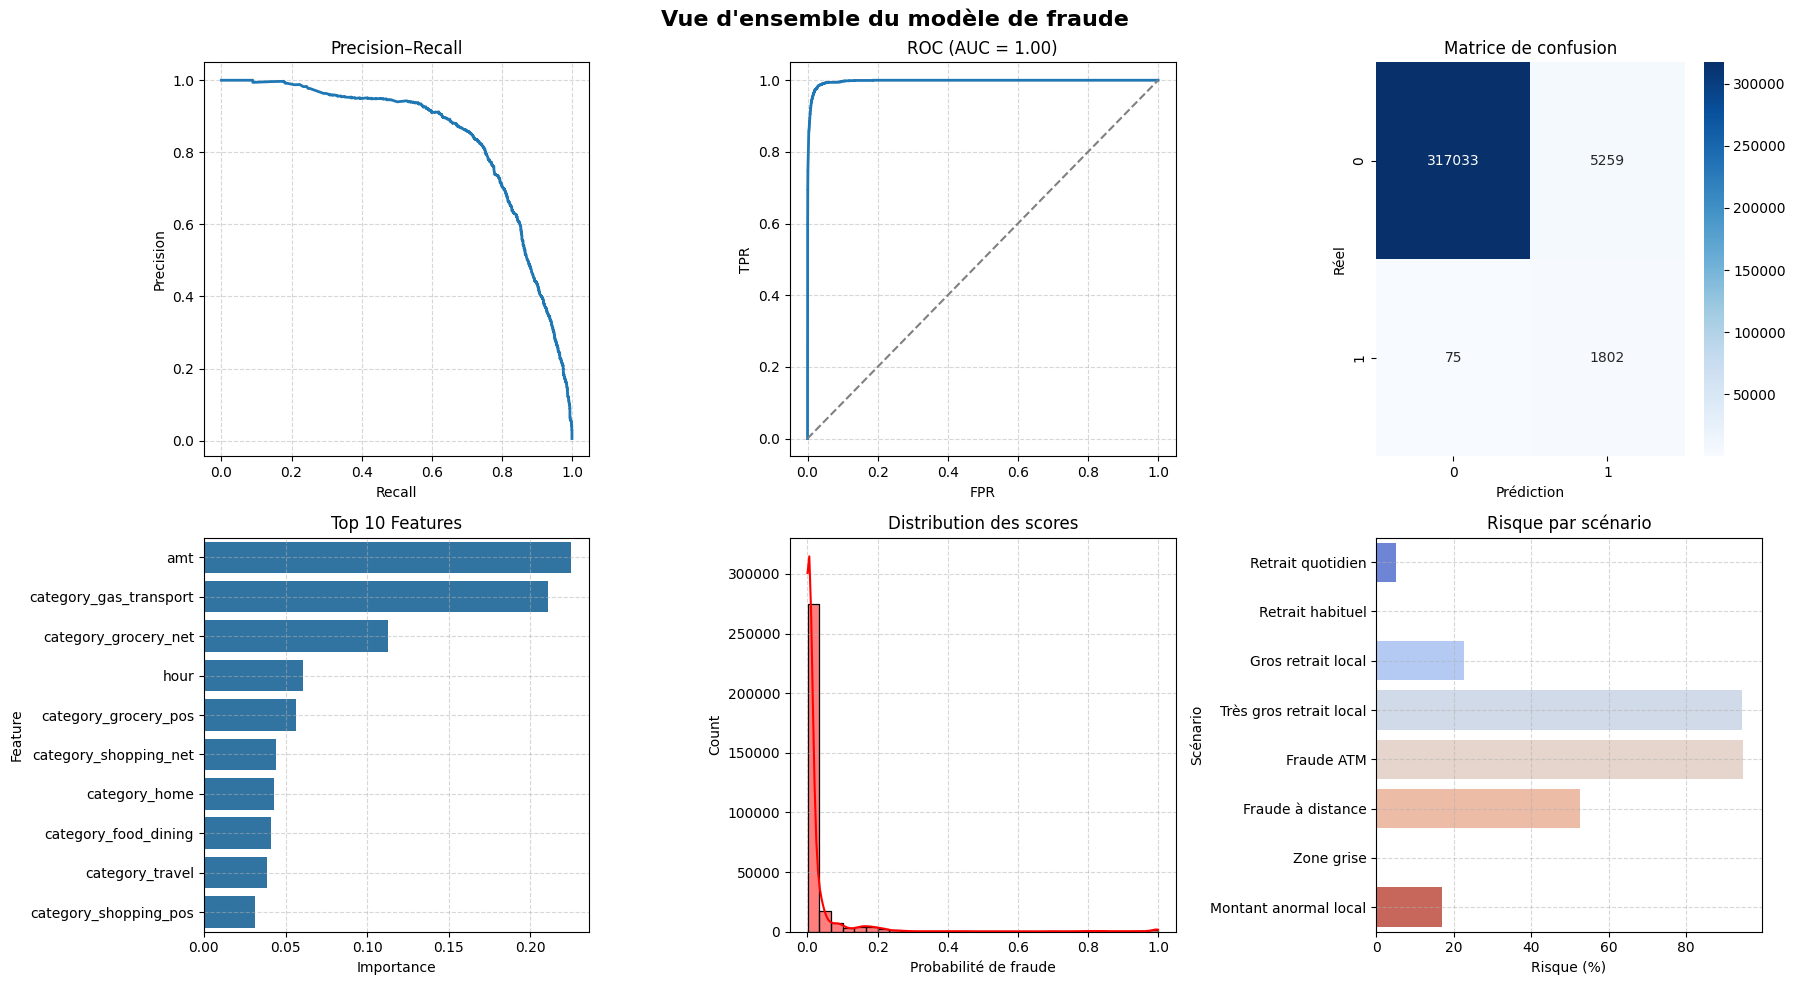

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    average_precision_score
)
import numpy as np
import pandas as pd

# --- Prédictions ---
y_scores = model_xgb.predict_proba(X_test)[:, 1]
y_pred = model_xgb.predict(X_test)

# --- Calculs ---
precision, recall, _ = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_scores)

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

cm = confusion_matrix(y_test, y_pred)

importances = model_xgb.feature_importances_
features = X.columns.tolist()
df_imp = pd.DataFrame({"Feature": features, "Importance": importances}).sort_values(by="Importance", ascending=False)

# --- Scénarios (exemple) ---
scenarios = {
    "Retrait quotidien": 5.07,
    "Retrait habituel": 0.10,
    "Gros retrait local": 22.72,
    "Très gros retrait local": 94.47,
    "Fraude ATM": 94.73,
    "Fraude à distance": 52.55,
    "Zone grise": 0.29,
    "Montant anormal local": 17.11,
}
df_scenarios = pd.DataFrame(list(scenarios.items()), columns=["Scénario", "Risque (%)"])

# --- FIGURE 2×3 ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Vue d'ensemble du modèle de fraude", fontsize=16, fontweight="bold")

# 1. Precision–Recall
axes[0, 0].plot(recall, precision, linewidth=2)
axes[0, 0].set_title("Precision–Recall")
axes[0, 0].set_xlabel("Recall")
axes[0, 0].set_ylabel("Precision")
axes[0, 0].grid(True, linestyle="--", alpha=0.5)

# 2. ROC
axes[0, 1].plot(fpr, tpr, linewidth=2)
axes[0, 1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0, 1].set_title(f"ROC (AUC = {roc_auc:.2f})")
axes[0, 1].set_xlabel("FPR")
axes[0, 1].set_ylabel("TPR")
axes[0, 1].grid(True, linestyle="--", alpha=0.5)

# 3. Matrice de confusion
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0, 2])
axes[0, 2].set_title("Matrice de confusion")
axes[0, 2].set_xlabel("Prédiction")
axes[0, 2].set_ylabel("Réel")

# 4. Importance des features
sns.barplot(x="Importance", y="Feature", data=df_imp.head(10), ax=axes[1, 0])
axes[1, 0].set_title("Top 10 Features")
axes[1, 0].grid(True, linestyle="--", alpha=0.5)

# 5. Distribution des scores
sns.histplot(y_scores, bins=30, kde=True, color="red", ax=axes[1, 1])
axes[1, 1].set_title("Distribution des scores")
axes[1, 1].set_xlabel("Probabilité de fraude")
axes[1, 1].grid(True, linestyle="--", alpha=0.5)

# 6. Barplot scénarios
sns.barplot(x="Risque (%)", y="Scénario", data=df_scenarios, palette="coolwarm", ax=axes[1, 2])
axes[1, 2].set_title("Risque par scénario")
axes[1, 2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

 Export  modele pour Streamlit

In [ ]:
import joblib

# 1. On sauvegarde l'intelligence du modèle (le cerveau)
joblib.dump(model_xgb, 'model_detection.joblib')

# 2. On demande au modèle : "Donne-moi la liste des colonnes que tu as apprises"

try:
    # essaie :feature_names: liste des noms de colonnes que le modèle a mémorisé pendant l'entraînement
    liste_colonnes = model_xgb.feature_names_in_
except:
    # sinon :récupérer les noms des colonnes. get_booster :le cerveau brut du traducteur, là où sont stockés tous ses dictionnaires et ses règles de grammaire XGboost
    liste_colonnes = model_xgb.get_booster().feature_names

# 3. On sauvegarde cette liste dans un fichier (le mode d'emploi pour l'interface)
joblib.dump(liste_colonnes, 'features_list.joblib')

print("Fichiers créés avec succès ! Tu peux les télécharger à gauche.")

Fichiers créés avec succès ! Tu peux les télécharger à gauche.
